In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from special_group import special_group

# === Paramètres ===
input_file = "var/new_table_2017-03-16.csv"
variables = ['V_lo_b', 'V_c_b', 'V_ex_b', 'V_lo_a', 'V_c_a', 'V_ex_a', 'mid_price']
lagmin = 0
lagmax = 20
group_amount = 10  # nombre d’événements à agréger

df = pd.read_csv(input_file)
# Agrégation
df_model = special_group(df, group_amount=group_amount)
df_model.head()

d:\OneDrive\Documents\Stud\S6\ST4  Modèle et agent en finance\st4-ei2-groupe2\special_group.py:41: UserWarning: Unexpected column found: bid_1
  warnings.warn(f"Unexpected column found: {col}")
d:\OneDrive\Documents\Stud\S6\ST4  Modèle et agent en finance\st4-ei2-groupe2\special_group.py:41: UserWarning: Unexpected column found: ask_1
  warnings.warn(f"Unexpected column found: {col}")


,datetime,V_lo_b,V_c_b,V_ex_b,V_lo_a,V_c_a,V_ex_a,mid_price,returns,deltaT
0,2017-03-16 09:30:03,600.0,200.0,0.0,800.0,1000.0,0.0,47.45000,0.000000,2.0
1,2017-03-16 09:30:04,230.0,230.0,0.0,900.0,1000.0,0.0,47.45200,0.000042,1.0
2,2017-03-16 09:30:04,349.0,190.0,0.0,394.0,750.0,0.0,47.45075,-0.000026,0.0
3,2017-03-16 09:30:09,1577.0,160.0,0.0,200.0,200.0,0.0,47.45250,0.000037,5.0
4,2017-03-16 09:30:09,370.0,1378.0,0.0,7.0,23.0,0.0,47.45250,0.000000,0.0



Sélection du lag optimal :
Lag   | AIC             | BIC             | HQIC           
--------------------------------------------------------
0     | 46.045064       | 46.047729       | 46.045927      
1     | 45.336932       | 45.360920       | 45.344707      
2     | 45.263224       | 45.308536       | 45.277910      
3     | 45.232490       | 45.299127       | 45.254087      
4     | 45.213279       | 45.301244       | 45.241789      
5     | 45.200600       | 45.309894       | 45.236023      
6     | 45.193532       | 45.324156       | 45.235868      
7     | 45.190431       | 45.342387       | 45.239681      
8     | 45.190004       | 45.363293       | 45.246168      
9     | 45.189335       | 45.383959       | 45.252415      
10    | 45.188650       | 45.404611       | 45.258645      
11    | 45.187904       | 45.425203       | 45.264816      
12    | 45.189220       | 45.447858       | 45.273048      
13    | 45.190385       | 45.470364       | 45.281130      
14    | 45.1920

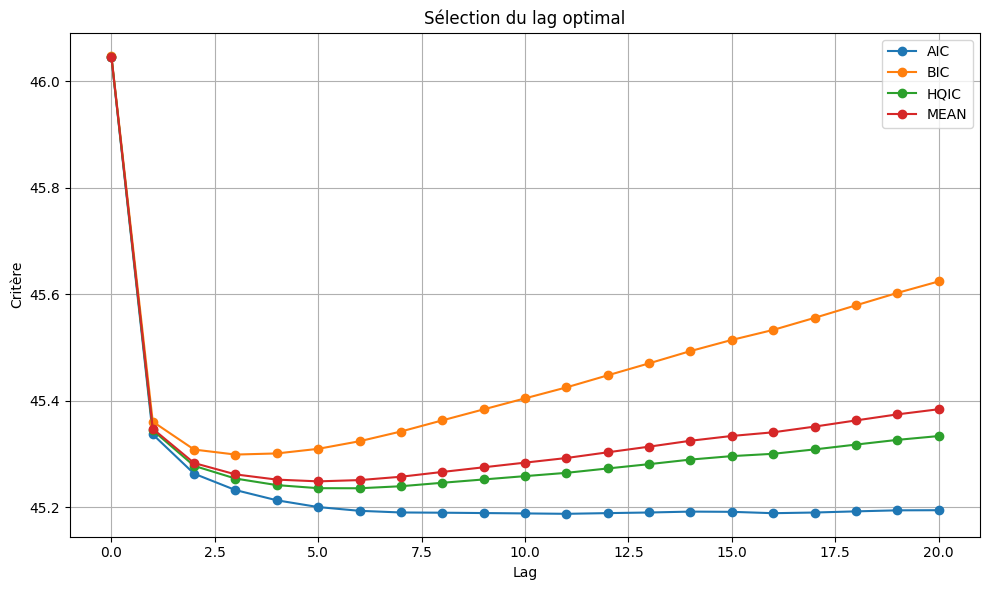

In [6]:
# === Lag selection ===
X = df_model.drop(columns=['datetime', 'mid_price'])
model = VAR(X)

results = {'lag': [], 'aic': [], 'bic': [], 'hqic': [], 'mean': []}

print("\nSélection du lag optimal :")
print(f"{'Lag':<5} | {'AIC':<15} | {'BIC':<15} | {'HQIC':<15}")
print("-" * 56)

for i in range(lagmin, lagmax + 1):
    try:
        res = model.fit(i)
        aic, bic, hqic = res.aic, res.bic, res.hqic
        print(f"{i:<5} | {aic:<15.6f} | {bic:<15.6f} | {hqic:<15.6f}")
        results['lag'].append(i)
        results['aic'].append(aic)
        results['bic'].append(bic)
        results['hqic'].append(hqic)
        results['mean'].append((aic + bic + hqic)/3)
    except Exception as e:
        print(f"{i:<5} | Erreur lors du fit : {e}")

# === Affichage des courbes ===
plt.figure(figsize=(10, 6))
plt.plot(results['lag'], results['aic'], label='AIC', marker='o')
plt.plot(results['lag'], results['bic'], label='BIC', marker='o')
plt.plot(results['lag'], results['hqic'], label='HQIC', marker='o')
plt.plot(results['lag'], results['mean'], label='MEAN', marker='o')
plt.xlabel('Lag')
plt.ylabel('Critère')
plt.title('Sélection du lag optimal')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()